In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")



Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [3]:
print(path)

/kaggle/input/chest-xray-pneumonia


In [4]:
import os

print(os.listdir(path))

['chest_xray']


In [5]:
dataset_dir = os.path.join(path, "chest_xray")

print(os.listdir(dataset_dir))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [7]:
import pandas as pd
from pathlib import Path

records = []

for split in ["train", "val", "test"]:
    split_path = Path(dataset_dir) / split

    for label in ["NORMAL", "PNEUMONIA"]:
        class_path = split_path / label

        for img_path in class_path.glob("*"):
            records.append({
                "filepath": str(img_path),
                "label": label,
                "split": split
            })

df = pd.DataFrame(records)

df.head()

,filepath,label,split
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train


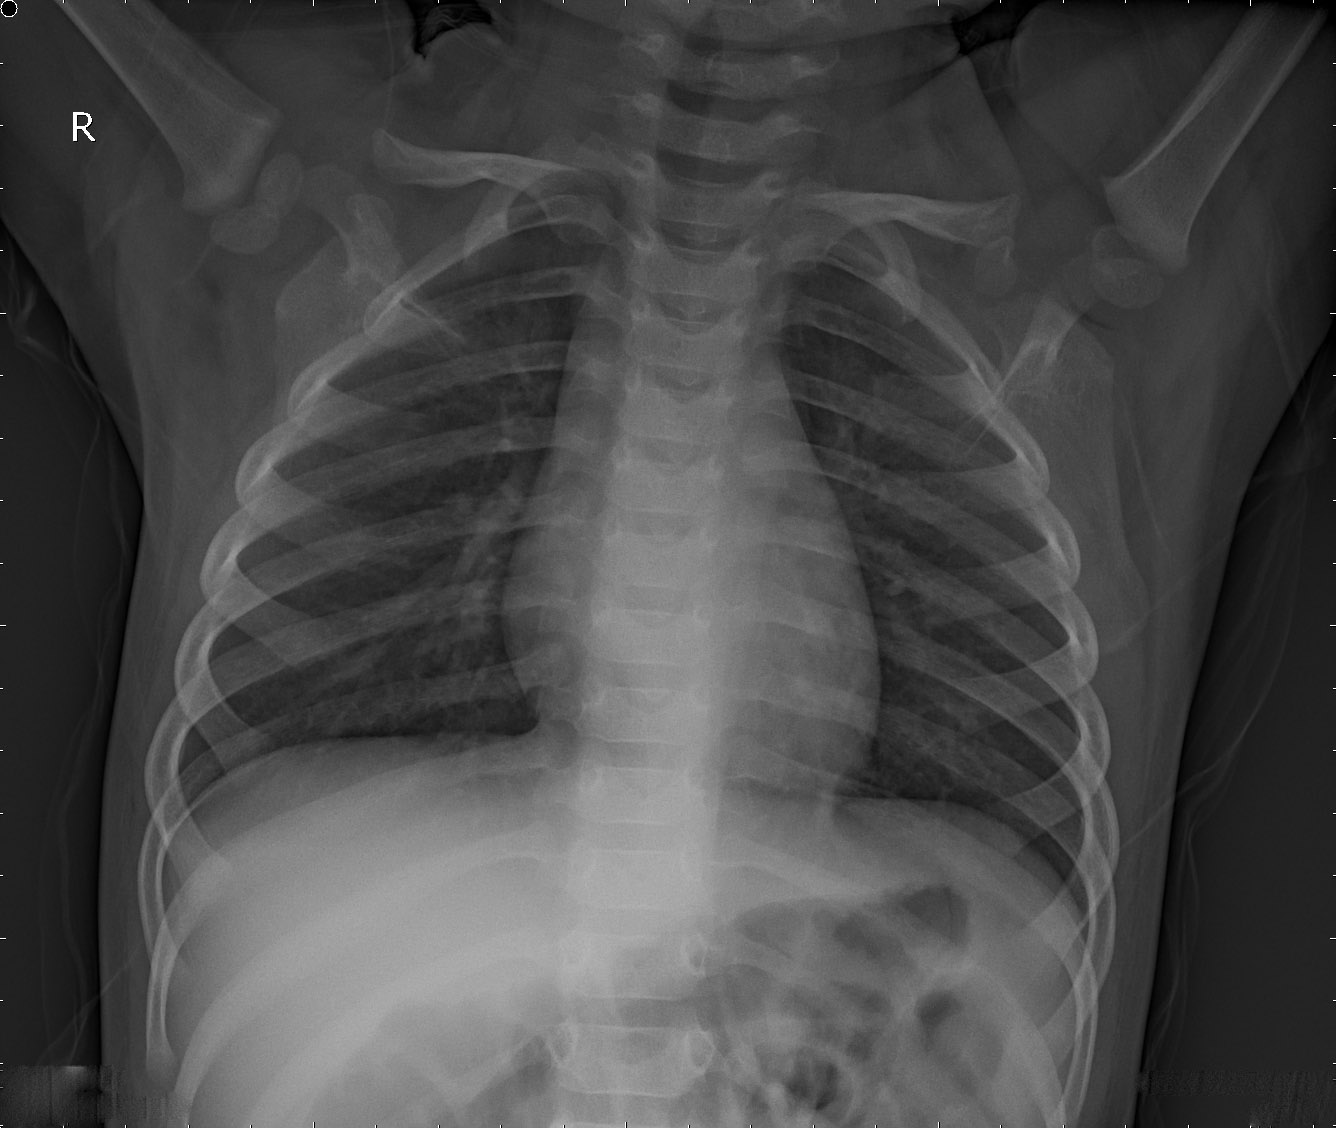

In [19]:
Image.open(df['filepath'][0])

In [8]:
df.shape

(5856, 3)

In [9]:
df["label"].value_counts()

,count
label,
PNEUMONIA,4273
NORMAL,1583


In [10]:
df.groupby(["split", "label"]).size()

split  label    
test   NORMAL        234
       PNEUMONIA     390
train  NORMAL       1341
       PNEUMONIA    3875
val    NORMAL          8
       PNEUMONIA       8
dtype: int64

In [11]:
from PIL import Image

widths = []
heights = []

for path in df["filepath"]:
    img = Image.open(path)

    widths.append(img.width)
    heights.append(img.height)

df["width"] = widths
df["height"] = heights

In [13]:
df

,filepath,label,split,width,height
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train,1336,1128
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train,1400,1260
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train,1218,1032
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train,1782,1433
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,train,1574,1129
...,...,...,...,...,...
5851,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,test,1264,744
5852,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,test,1400,1048
5853,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,test,1280,984
5854,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,test,1008,648


In [12]:
df[["width", "height"]].describe()

,width,height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


In [14]:
df["aspect_ratio"] = df["width"] / df["height"]

In [22]:
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

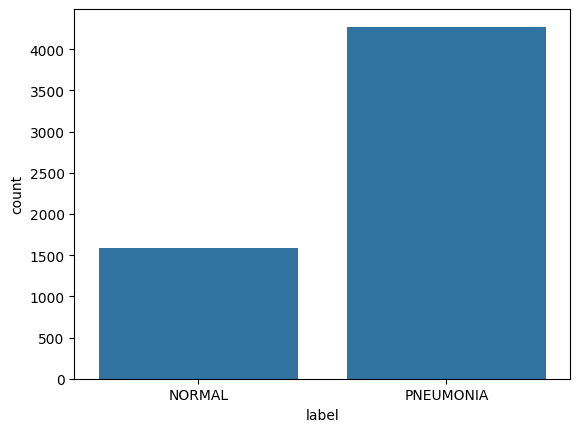

In [23]:
sns.countplot(data=df, x='label')

<Axes: xlabel='split', ylabel='count'>

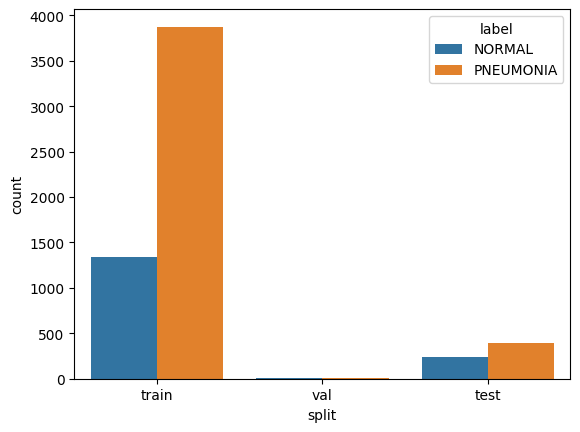

In [24]:
sns.countplot(
    data=df,
    x='split',
    hue='label'
)

<Axes: xlabel='width', ylabel='Count'>

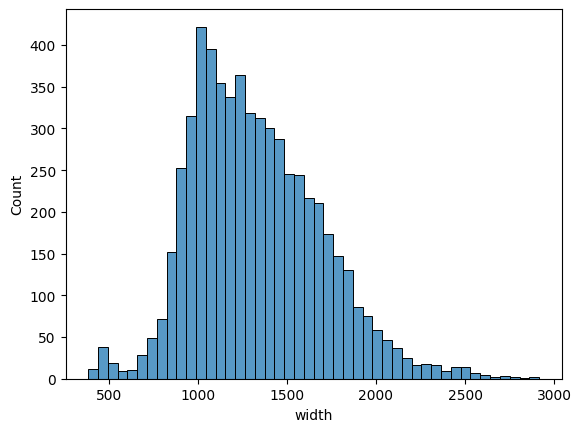

In [25]:
sns.histplot(df['width'])

<Axes: xlabel='height', ylabel='Count'>

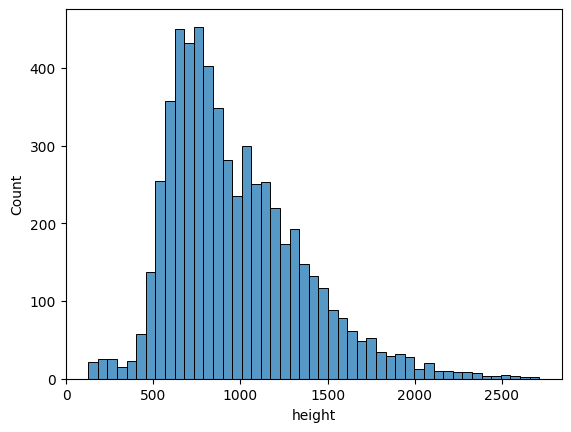

In [26]:
sns.histplot(df['height'])

In [ ]:
| Split | Images |
| ----- | -----: |
| Train |   5216 |
| Val   |     16 |
| Test  |    624 |


In [28]:
df["split"] = df["split"].replace("val", "train")